### <font color=skyblue>檢定統計量的顯著水準的維持與檢定力</font>

- 型一誤 (Type I Error)： 在虛無假設為真時，錯誤地拒絕虛無假設。
- 顯著水準（significance level）$\alpha$ 為預先設定承擔的風險水準。通常表示為

$$\alpha = P_{rob}(\text{拒絕 } H_0 | H_0 \text{ 為真})$$


- 檢定力 (Power) 為在對立假設為真時，成功地拒絕虛無假設的機率，即

$$Power = P_{rob}(\text{拒絕 } H_0 | H_a \text{ 為真})$$

檢定力越高，表示檢定方法越能有效地識別出對立假設為真的情況，與醫學統計中診斷測試的敏感度 (sensitivity)有相似的意思。

判斷檢定統計量的好壞，主要依據以下兩個標準：（皆與樣本數相關）
1. 維持型一誤機率在設定的顯著水準 $\alpha$ 。
1. 高檢定力。

<font color=yellow>顯著水準的維持</font>

以檢定統計量 $t$ 為例，假設虛無假設為 $H_0: \mu_1 = \mu_2$，對立假設為 $H_a: \mu_1 \neq \mu_2$，則型一誤機率為

$$\alpha = P_{rob}(\text{拒絕 } H_0 | H_0 \text{ 為真}) $$

設定顯著水準 $\alpha = 0.05$，樣本數 $n_1=n_2= 10, 20, 30, 50, 100, 300, 500 $, 實驗次數 $N=10000$， 計算發生型一誤的比例，以此做為檢定統計量 $t$ 的型一誤維持能力的評估。想知道是否 $\alpha$ 的設定值能夠被維持，並且隨著樣本數的增加，型一誤的比例是否會趨近於預先設定的 $\alpha$。

#### 檢定統計量的顯著水準的維持與檢定力：use two defs

In [42]:
def draw_rejection_ratio(mu1, mu2, s1, s2, n, N=50000, alfa=0.05):
    # loop over different sample sizes and record the proportion of times the null hypothesis is rejected
    # keep the rejection ratio for each sample size
    rejection_ratios = []

    for n_val in n:
        samples1 = np.random.normal(mu1, s1, size=(n_val, N))
        samples2 = np.random.normal(mu2, s2, size=(n_val, N))

        # compute t statistic
        t_statistic, p_value = ttest_ind(samples1, samples2)

        reject_ratio = np.mean(p_value < alfa)
        rejection_ratios.append(reject_ratio)

    return rejection_ratios

def plot_rejection_ratio(n, rejection_ratios, y_low=0, y_high=1.2, y_label='Rejection Ratio'):
    import matplotlib.pyplot as plt

    # plot the rejection ratio against sample size
    fig = plt.figure(figsize=(6, 3))
    x = np.arange(len(n))
    plt.plot(x, rejection_ratios, marker='o')
    plt.xticks(x, n)
    plt.title('Rejection Ratio vs Sample Size')
    plt.xlabel('Sample Size (n)')
    plt.ylabel(y_label)
    # add grid lines
    plt.grid()
    # expand the y-axis to show the rejection ratio more clearly
    plt.ylim(y_low, y_high)
    plt.show()

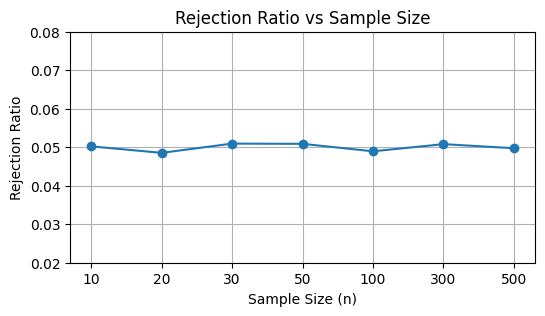

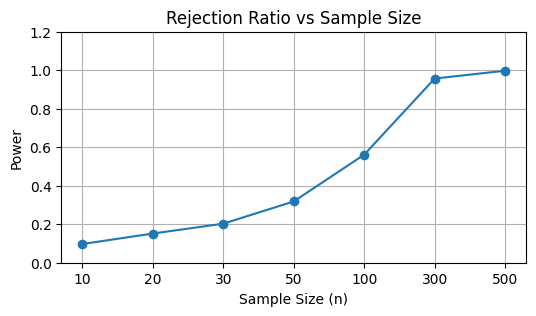

In [44]:
n = [10, 20, 30, 50, 100, 300, 500]

rejection_ratios = draw_rejection_ratio(0, 0, 1, 1, n, N=50000, alfa=0.05)
plot_rejection_ratio(n, rejection_ratios, y_low=0.02, y_high=0.08)

rejection_ratios = draw_rejection_ratio(0, 0.3, 1, 1, n, N=50000, alfa=0.05)
plot_rejection_ratio(n, rejection_ratios, y_low=0, y_high=1.2, y_label='Power')

Rejection ratios: [0.04754, 0.0497, 0.05104, 0.04908, 0.04902, 0.0507, 0.05092]


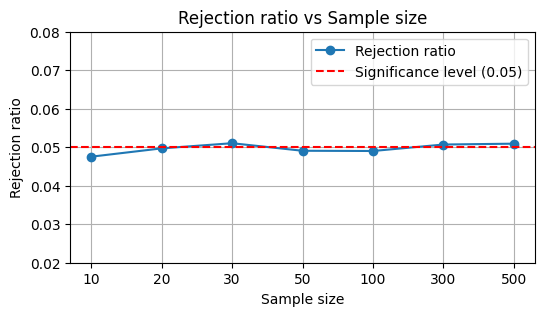

In [34]:
import numpy as np
from scipy.stats import ttest_ind
# take n samples from a normal distribution with mean 0 and standard deviation 1
# repeat this sampling N times to create two independent samples
N = 50000
n = [10, 20, 30, 50, 100, 300, 500]
alfa = 0.05
# loop over different sample sizes and record the proportion of times the null hypothesis is rejected
# keep the rejection ratio for each sample size
rejection_ratios = []

for n_val in n:
    samples1 = np.random.normal(0, 1, size=(n_val, N))
    samples2 = np.random.normal(0, 1, size=(n_val, N))

    # compute t statistic
    t_statistic, p_value = ttest_ind(samples1, samples2)

    reject_ratio = np.mean(p_value < alfa)
    # print(f"Sample size: {n_val}, Reject ratio: {reject_ratio:.4f}")
    rejection_ratios.append(reject_ratio)

print(f"Rejection ratios: {rejection_ratios}")
# draw a plot of the rejection ratios against the sample sizes
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(6, 3))

x = range(len(n))
plt.plot(x, rejection_ratios, 'o-', label='Rejection ratio')
plt.xticks(x, n)
# draw a horizontal line at y=0.05
plt.axhline(y=alfa, color='r', linestyle='--', label='Significance level (0.05)')
plt.xlabel("Sample size")
plt.ylabel("Rejection ratio")

# add a legend
plt.legend()
plt.title("Rejection ratio vs Sample size")
# add grid lines
plt.grid()
# expand the y-axis to show the rejection ratio more clearly
plt.ylim(0.02, 0.08)
plt.show()


<font color=yellow>檢定力 Power 的評估</font>

- 假設兩樣本分別來自常態 $N(0,1)$ 與 $N(0.5,1)$，即對立假設為真時，檢定統計量 $t$ 在不同樣本數的檢定力的表現如何？樣本數與實驗次數同上。
- 若假設兩樣本分別來自常態 $N(0,1)$ 與 $N(1,1)$，則結果如何？
- 若假設兩樣本分別來自常態 $N(0,1)$ 與 $N(0.3,1)$，則結果如何？

Rejection ratios: [0.09944, 0.15542, 0.20504, 0.32006, 0.55772, 0.95698, 0.99716]


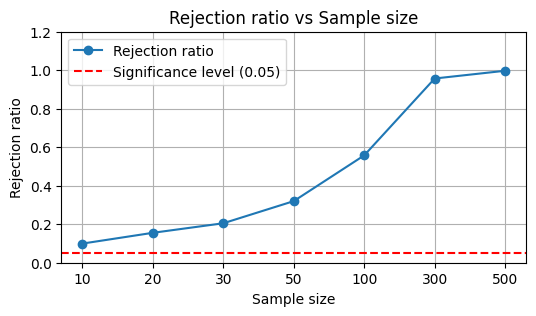

In [37]:
import numpy as np
from scipy.stats import ttest_ind
# take n samples from a normal distribution with mean 0 and standard deviation 1
# repeat this sampling N times to create two independent samples
N = 50000
n = [10, 20, 30, 50, 100, 300, 500]
alfa = 0.05
# loop over different sample sizes and record the proportion of times the null hypothesis is rejected
# keep the rejection ratio for each sample size
rejection_ratios = []
mu1, s1 = 0, 1
mu2, s2 = 0.3, 1

for n_val in n:
    samples1 = np.random.normal(mu1, s1, size=(n_val, N))
    samples2 = np.random.normal(mu2, s2, size=(n_val, N))

    # compute t statistic
    t_statistic, p_value = ttest_ind(samples1, samples2)

    reject_ratio = np.mean(p_value < alfa)
    # print(f"Sample size: {n_val}, Reject ratio: {reject_ratio:.4f}")
    rejection_ratios.append(reject_ratio)

print(f"Rejection ratios: {rejection_ratios}")
# draw a plot of the rejection ratios against the sample sizes
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(6, 3))

x = range(len(n))
plt.plot(x, rejection_ratios, 'o-', label='Rejection ratio')
plt.xticks(x, n)
# draw a horizontal line at y=0.05
plt.axhline(y=alfa, color='r', linestyle='--', label='Significance level (0.05)')
plt.xlabel("Sample size")
plt.ylabel("Rejection ratio")

# add a legend
plt.legend()
plt.title("Rejection ratio vs Sample size")
# add grid lines
plt.grid()
# expand the y-axis to show the rejection ratio more clearly
plt.ylim(0, 1.2)
plt.show()
